<a href="https://colab.research.google.com/github/Csoumya2002/Customer-Segmentation-and-Prediction-of-Term-Deposit-Subscriptions-in-Bank-Marketing/blob/main/Bank_Data(Clustering).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df1 = pd.read_csv('bank-additional-full.csv')
df1.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:
df1[df1.duplicated(keep=False)]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1265,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
1266,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
12260,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
14155,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16819,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16956,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
18464,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no


In [ ]:
df1=df1.drop_duplicates()

In [ ]:
month_to_number = {
    'jan': 1,
    'feb': 2,
    'mar': 3,
    'apr': 4,
    'may': 5,
    'jun': 6,
    'jul': 7,
    'aug': 8,
    'sep': 9,
    'oct': 10,
    'nov': 11,
    'dec': 12
}

# Map month names to numbers
df1['month'] = df1['month'].map(month_to_number)

In [ ]:
day_to_number = {
    'mon': 1,
    'tue': 2,
    'wed': 3,
    'thu': 4,
    'fri': 5,
    'sat': 6,
    'sun': 7
}

# Map month names to numbers
df1['day_of_week'] = df1['day_of_week'].map(day_to_number)

In [ ]:
label=LabelEncoder()
df1['y']=label.fit_transform(df1['y'])
label_dict = dict(zip(label.classes_, label.transform(label.classes_)))
print(label_dict)

{'no': np.int64(0), 'yes': np.int64(1)}


In [ ]:
def convert_pdays(value):
    if value == 999:
        return 'Never Contacted'
    elif value <= 7:
        return 'recently contacted'
    elif 8 <= value <= 30:
        return 'sometimes ago'
    else:
        return 'long ago'

df1['pdays_new'] = df1['pdays'].apply(convert_pdays)

In [ ]:
df1.drop('pdays', axis=1, inplace=True)

In [ ]:
# Separate features and target
target = df1["y"]
features = df1.drop("y", axis=1)

# Identify categorical and numerical columns
categorical_cols = features.select_dtypes(include=["object"]).columns
numerical_cols = features.drop(columns=categorical_cols)

# One-hot encode categorical columns and convert to int (0/1)
encoded_cats = pd.get_dummies(features[categorical_cols], drop_first=True).astype(int)

# Combine numerical + encoded
X_encoded = pd.concat([numerical_cols, encoded_cats], axis=1)

# add target back
df_final = pd.concat([X_encoded, target], axis=1)
print(df_final.head())

   age  month  day_of_week  duration  campaign  previous  emp.var.rate  \
0   56      5            1       261         1         0           1.1   
1   57      5            1       149         1         0           1.1   
2   37      5            1       226         1         0           1.1   
3   40      5            1       151         1         0           1.1   
4   56      5            1       307         1         0           1.1   

   cons.price.idx  cons.conf.idx  euribor3m  ...  housing_unknown  \
0          93.994          -36.4      4.857  ...                0   
1          93.994          -36.4      4.857  ...                0   
2          93.994          -36.4      4.857  ...                0   
3          93.994          -36.4      4.857  ...                0   
4          93.994          -36.4      4.857  ...                0   

   housing_yes  loan_unknown  loan_yes  contact_telephone  \
0            0             0         0                  1   
1            0    

In [ ]:
df_final.to_csv('bank_data_cleaned.csv',index=False)

In [ ]:
df=pd.read_csv('bank_data_cleaned.csv')
df.head()

,age,month,day_of_week,duration,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,...,housing_unknown,housing_yes,loan_unknown,loan_yes,contact_telephone,poutcome_nonexistent,poutcome_success,pdays_new_recently contacted,pdays_new_sometimes ago,y
0,56,5,1,261,1,0,1.1,93.994,-36.4,4.857,...,0,0,0,0,1,1,0,0,0,0
1,57,5,1,149,1,0,1.1,93.994,-36.4,4.857,...,0,0,0,0,1,1,0,0,0,0
2,37,5,1,226,1,0,1.1,93.994,-36.4,4.857,...,0,1,0,0,1,1,0,0,0,0
3,40,5,1,151,1,0,1.1,93.994,-36.4,4.857,...,0,0,0,0,1,1,0,0,0,0
4,56,5,1,307,1,0,1.1,93.994,-36.4,4.857,...,0,0,0,1,1,1,0,0,0,0


In [ ]:
df.isnull().sum()

,0
age,0
month,0
day_of_week,0
duration,0
campaign,0
previous,0
emp.var.rate,0
cons.price.idx,0
cons.conf.idx,0
euribor3m,0


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df.drop('y', axis=1)
vif = pd.DataFrame()
vif['Feature'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif = vif[vif['Feature'] != 'const']
print(vif[vif['VIF'] > 10])

                         Feature           VIF
0                            age  2.642265e+01
1                          month  2.258891e+01
6                   emp.var.rate  4.137239e+01
7                 cons.price.idx  3.524204e+04
8                  cons.conf.idx  1.261605e+02
9                      euribor3m  3.592547e+02
10                   nr.employed  4.004177e+04
34               housing_unknown           inf
36                  loan_unknown           inf
39          poutcome_nonexistent  3.776616e+01
40              poutcome_success  1.301915e+01
41  pdays_new_recently contacted  1.257112e+01


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

def compute_vif(X):
    X = sm.add_constant(X)
    vif_data = pd.DataFrame()
    vif_data['Feature'] = X.columns
    vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_data[vif_data["Feature"] != "const"].sort_values(by="VIF", ascending=False)

X = df.drop(columns=['y'])

drop_order = [
    'nr.employed','housing_unknown', 'emp.var.rate','poutcome_success', 'cons.price.idx', 'cons.conf.idx',
    'loan_unknown', 'poutcome_nonexistent',
    'pdays_new_recently contacted', 'age'
]

for col in drop_order:
    if col in X.columns:
        X.drop(columns=col, inplace=True)
        vif = compute_vif(X)
        print(f"Dropped: {col}")
        print(vif.head())
        if all(vif["VIF"] < 10):
            print("All VIFs below 10. Multicollinearity removed.")
            break

Dropped: nr.employed
             Feature        VIF
34   housing_unknown        inf
36      loan_unknown        inf
7       emp.var.rate  47.116362
10         euribor3m  40.164740
40  poutcome_success  12.581897
Dropped: housing_unknown
                         Feature        VIF
7                   emp.var.rate  47.116362
10                     euribor3m  40.164740
39              poutcome_success  12.581897
40  pdays_new_recently contacted  12.218424
6                       previous   5.975126
Dropped: emp.var.rate
                         Feature        VIF
38              poutcome_success  12.568401
39  pdays_new_recently contacted  12.198720
6                       previous   5.934629
37          poutcome_nonexistent   5.117649
29   education_university.degree   4.168104
Dropped: poutcome_success
                        Feature       VIF
6                      previous  5.470544
37         poutcome_nonexistent  4.839721
29  education_university.degree  4.167971
9                 

In [ ]:
# Combine back with target variable
target = df["y"]
df_no_multicollinearity = pd.concat([X, target], axis=1)

output_file = "bank_data_no_multicollinearity.csv"
df_no_multicollinearity.to_csv(output_file, index=False)
print(f"\n Cleaned dataset saved as: {output_file}")


 Cleaned dataset saved as: bank_data_no_multicollinearity.csv


In [ ]:
df=pd.read_csv('bank_data_no_multicollinearity.csv')
df.head()

,age,month,day_of_week,duration,campaign,previous,cons.price.idx,cons.conf.idx,euribor3m,job_blue-collar,...,default_unknown,default_yes,housing_yes,loan_unknown,loan_yes,contact_telephone,poutcome_nonexistent,pdays_new_recently contacted,pdays_new_sometimes ago,y
0,56,5,1,261,1,0,93.994,-36.4,4.857,0,...,0,0,0,0,0,1,1,0,0,0
1,57,5,1,149,1,0,93.994,-36.4,4.857,0,...,1,0,0,0,0,1,1,0,0,0
2,37,5,1,226,1,0,93.994,-36.4,4.857,0,...,0,0,1,0,0,1,1,0,0,0
3,40,5,1,151,1,0,93.994,-36.4,4.857,0,...,0,0,0,0,0,1,1,0,0,0
4,56,5,1,307,1,0,93.994,-36.4,4.857,0,...,0,0,0,0,1,1,1,0,0,0


In [ ]:
!pip install prince

# **----------  KMEANS  ----------**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
import prince

# Use X_encoded which contains both numerical and one-hot encoded categorical features
df_processed = df.copy()

# Numerical columns
numeric_cols = ['age', 'month', 'day_of_week', 'duration', 'campaign', 'previous',
                 'cons.price.idx', 'cons.conf.idx',
                'euribor3m']

# One-hot encoded categorical columns are all columns in df_processed that are not in numeric_cols
categorical_cols_encoded = [col for col in df_processed.columns if col not in numeric_cols]


# PCA on numerical features
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(df_processed[numeric_cols])

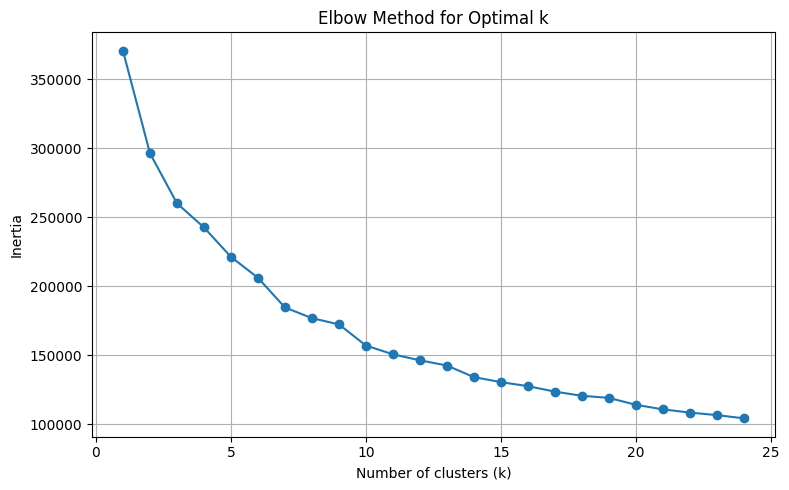

In [ ]:
# Elbow method to determine optimal k
inertia = []
k_range = range(1, 25)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_num_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
pca = PCA(n_components=9, random_state=42)  # retain 95% variance
X_pca = pca.fit_transform(X_num_scaled)
pca_cols = [f'PC{i+1}' for i in range(X_pca.shape[1])]
df_pca = pd.DataFrame(X_pca, columns=pca_cols)

In [ ]:
# Clustering - KMeans
kmeans = KMeans(n_clusters=6, random_state=42)
kmeans_labels = kmeans.fit_predict(df_pca)
print("KMeans Silhouette Score:", silhouette_score(df_pca, kmeans_labels))

KMeans Silhouette Score: 0.1937680064374444


In [ ]:
import umap.umap_ as umap

# Reduce to 10D using UMAP
umap_model = umap.UMAP(n_components=10, random_state=42)
X_umap = umap_model.fit_transform(df_pca)

# Apply KMeans
kmeans = KMeans(n_clusters=6, random_state=42)
labels = kmeans.fit_predict(X_umap)
print("Silhouette Score (UMAP + KMeans):", silhouette_score(X_umap, labels))

Silhouette Score (UMAP + KMeans): 0.5065011


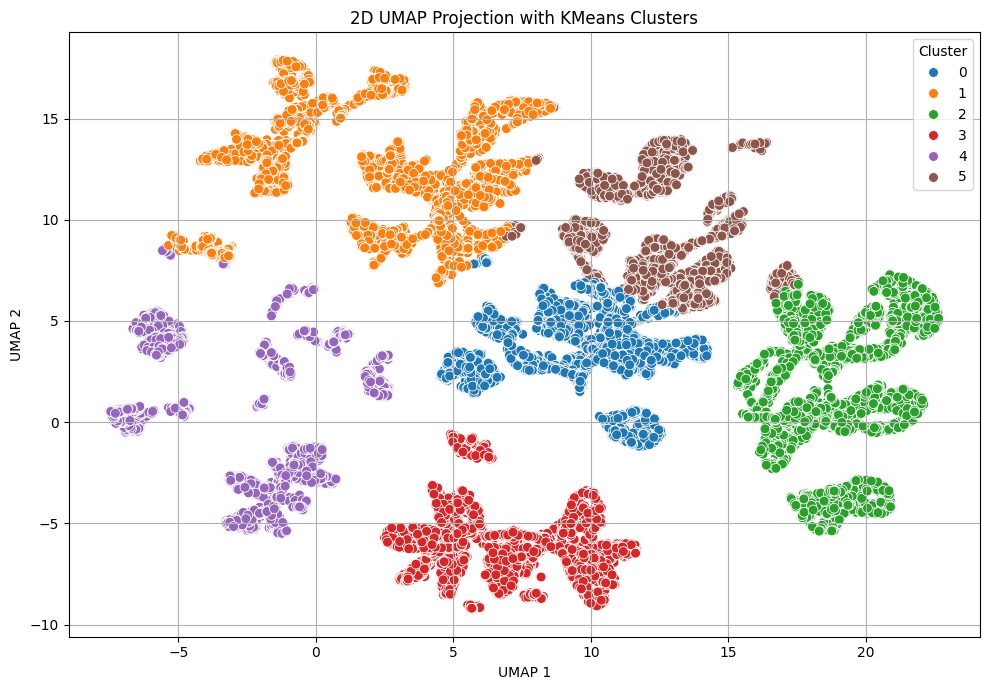

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# Reduce to 2D using UMAP for visualization
umap_2d = umap.UMAP(n_components=2, random_state=42)
X_umap_2d = umap_2d.fit_transform(df_pca)

# KMeans clustering
kmeans = KMeans(n_clusters=6, random_state=42)
cluster_labels = kmeans.fit_predict(X_umap_2d)

# Visualize UMAP Clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_umap_2d[:, 0], y=X_umap_2d[:, 1], hue=cluster_labels, palette='tab10', s=50)
plt.title("2D UMAP Projection with KMeans Clusters")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px

# UMAP to 3D
umap_3d = umap.UMAP(n_components=3, random_state=42)
X_umap_3d = umap_3d.fit_transform(df_pca)

# KMeans clustering
kmeans = KMeans(n_clusters=6, random_state=42)
cluster_labels = kmeans.fit_predict(X_umap_3d)

# Prepare DataFrame for Plotly
df_umap_3d = pd.DataFrame(X_umap_3d, columns=["UMAP1", "UMAP2", "UMAP3"])
df_umap_3d["Cluster"] = cluster_labels.astype(str)

# Plotly 3D scatter plot
fig = px.scatter_3d(df_umap_3d, x="UMAP1", y="UMAP2", z="UMAP3",
                    color="Cluster", title="3D UMAP Projection with KMeans Clusters",
                    opacity=0.7, width=900, height=700)
fig.show()

# **---------- Agglomerative ----------**

In [ ]:
'''# Clustering - Agglomerative
agg = AgglomerativeClustering(n_clusters=6)
agg_labels = agg.fit_predict(df_pca)
print("Agglomerative Silhouette Score:", silhouette_score(df_pca, agg_labels))'''

In [ ]:
# Subsample to 8000 rows (or fewer)
df_sampled = df_pca.sample(n=8000, random_state=42)

# Apply Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=6)
labels = agg.fit_predict(df_sampled)

from sklearn.metrics import silhouette_score
print("Silhouette Score (PCA + Agglomerative):", silhouette_score(df_sampled, labels))

Silhouette Score (PCA + Agglomerative): 0.21408152911981254


In [ ]:
# Assign cluster labels back to original data
df['Cluster'] = kmeans_labels

# Profile clusters
cluster_summary = df.groupby('Cluster').mean(numeric_only=True)
print("\nCluster Profile Summary:")
print(cluster_summary)


Cluster Profile Summary:
               age     month  day_of_week    duration  campaign  previous  \
Cluster                                                                     
0        39.444843  5.936249     4.033529  290.134586  2.273328  0.000000   
1        37.976633  4.706950     2.951332  264.074713  2.241851  0.000000   
2        40.488861  6.314735     1.659371  240.354505  3.836037  0.000098   
3        39.332831  5.466365     3.020833  274.937751  2.020582  1.308233   
4        44.649793  9.259549     3.005983  273.699494  1.789231  0.542568   
5        41.070340  9.504814     3.289917  219.344745  2.060177  0.097887   

         cons.price.idx  cons.conf.idx  euribor3m  job_blue-collar  ...  \
Cluster                                                             ...   
0             94.075673     -39.723819   4.823941         0.284001  ...   
1             92.970655     -45.866915   1.314777         0.264325  ...   
2             93.984082     -39.495515   4.829506        

In [ ]:
# Subsample to 8000 rows for efficiency
df_sampled = df_pca.sample(n=8000, random_state=42)

# Apply UMAP for dimensionality reduction to 10D
umap_model = umap.UMAP(n_components=10, random_state=42)
X_umap = umap_model.fit_transform(df_sampled)

# Apply Agglomerative Clustering on reduced data
agg = AgglomerativeClustering(n_clusters=6)
labels = agg.fit_predict(X_umap)

# Calculate silhouette score
sil_score = silhouette_score(X_umap, labels)
print(f"Silhouette Score (UMAP + Agglomerative Clustering): {sil_score:.4f}")

Silhouette Score (UMAP + Agglomerative Clustering): 0.6920


In [ ]:
import plotly.express as px

# Subsample to 8000 rows for efficiency
df_sampled = df_pca.sample(n=8000, random_state=42)

# Apply UMAP for dimensionality reduction to 10D
umap_model = umap.UMAP(n_components=3, random_state=42)
X_umap = umap_model.fit_transform(df_sampled)

# Convert to DataFrame for Plotly
df_plot = pd.DataFrame(X_umap, columns=['UMAP1', 'UMAP2', 'UMAP3'])
df_plot["Cluster"] = labels.astype(str)  # Convert to string for color separation

# Interactive 3D Scatter Plot
fig = px.scatter_3d(df_plot, x='UMAP1', y='UMAP2', z='UMAP3',
                    color='Cluster', opacity=0.7,
                    title='Interactive 3D UMAP + Agglomerative Clustering',
                    width=900, height=700)
fig.show()

# **---------  DBSCAN  ---------**

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# Drop target variable if exists
if "y" in df.columns:
    X = df.drop(columns=["y"])
else:
    X = df.copy()

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA to reduce dimensions (retain 95% variance)
pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Fit DBSCAN
dbscan = DBSCAN(eps=5, min_samples=5)
clusters = dbscan.fit_predict(X_pca)

# Add cluster labels
df["Cluster"] = clusters

# Mask to remove noise points
mask = clusters != -1
filtered_labels = clusters[mask]

# Check: are there at least 2 unique clusters (excluding noise)?
if len(set(filtered_labels)) >= 2:
    sil_score = silhouette_score(X_umap[mask], filtered_labels)
    print(f"Silhouette Score (PCA + DBSCAN): {sil_score:.4f}")
else:
    print("Silhouette Score cannot be calculated: only one cluster (or all noise).")

Silhouette Score cannot be calculated: only one cluster (or all noise).


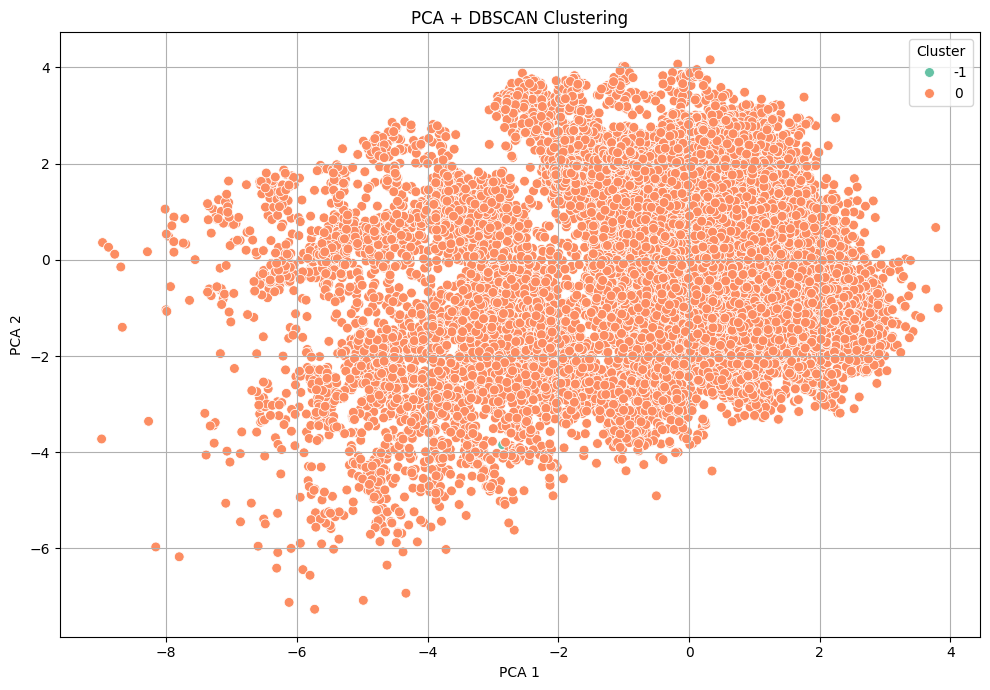

In [ ]:
# Visualize in 2D (first 2 PCA components)
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette="Set2", s=50)
plt.title("PCA + DBSCAN Clustering")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import umap.umap_ as umap
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

X = df.drop(columns=["y"], errors="ignore")

# Apply UMAP to reduce to 2D for clustering and visualization
umap_model = umap.UMAP(n_components=2, random_state=42)
X_umap = umap_model.fit_transform(X)

# Apply DBSCAN clustering
dbscan = DBSCAN(eps=1, min_samples=5) # Reduced eps
clusters = dbscan.fit_predict(X_umap)

# Evaluate clustering (ignoring noise points)
mask = clusters != -1
if mask.sum() > 1 and len(set(clusters[mask])) > 1:
    sil_score = silhouette_score(X_umap[mask], clusters[mask])
    print(f"Silhouette Score (UMAP + DBSCAN): {sil_score:.4f}")
elif mask.sum() <= 1:
    print("Too many noise points or only one point to calculate Silhouette Score.")
else:
     print("Silhouette Score cannot be calculated: only one cluster (excluding noise).")

Silhouette Score (UMAP + DBSCAN): -0.2305


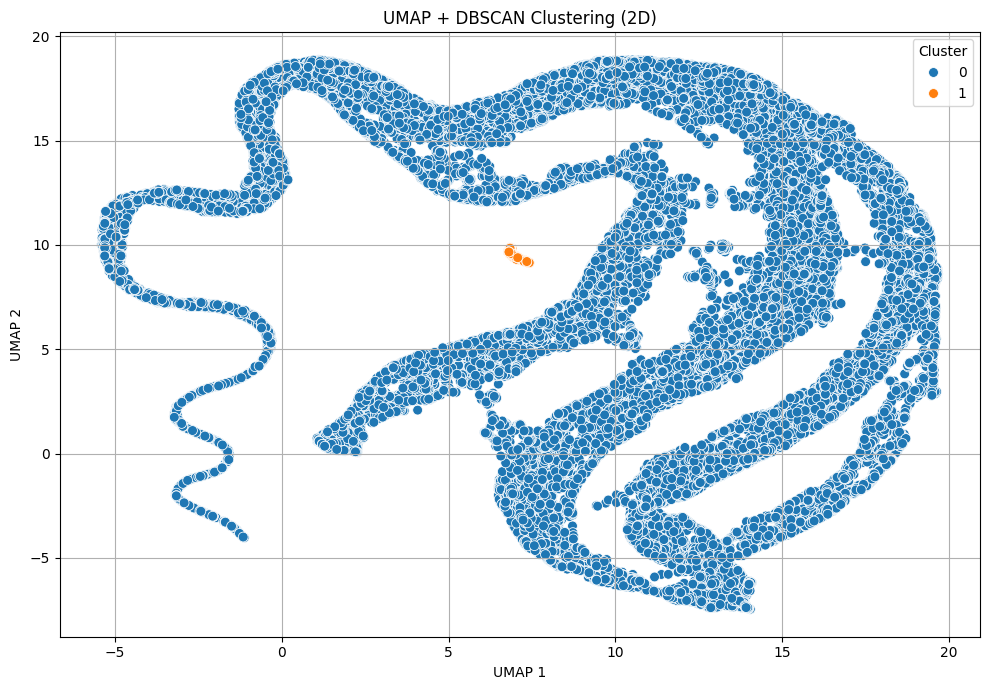

In [ ]:
# Visualize Clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=clusters, palette="tab10", s=50)
plt.title("UMAP + DBSCAN Clustering (2D)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_L=pd.read_csv('bank-additional-full.csv')
df_L.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:
df_L=df_L.drop_duplicates()

In [ ]:
def convert_pdays(value):
    if value == 999:
        return 'Never Contacted'
    elif value <= 7:
        return 'recently contacted'
    elif 8 <= value <= 30:
        return 'sometimes ago'
    else:
        return 'long ago'

df_L['pdays_new'] = df_L['pdays'].apply(convert_pdays)

In [ ]:
df_L.drop('pdays', axis=1, inplace=True)

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns
categorical_cols = df_L.select_dtypes(include=['object', 'category']).columns.tolist()

# Apply Label Encoding to each categorical column
label_encoders = {}  # Store encoders if you want to inverse-transform later
for col in categorical_cols:
    le = LabelEncoder()
    df_L[col] = le.fit_transform(df_L[col])
    label_encoders[col] = le

In [ ]:
df_L.to_csv('bank_data_cleaned1.csv',index=False)

In [ ]:
df_C=pd.read_csv('bank_data_cleaned1.csv')
df_C.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,pdays_new
0,56,3,1,0,0,0,0,1,6,1,...,1,0,1,1.1,93.994,-36.4,4.857,5191.0,0,0
1,57,7,1,3,1,0,0,1,6,1,...,1,0,1,1.1,93.994,-36.4,4.857,5191.0,0,0
2,37,7,1,3,0,2,0,1,6,1,...,1,0,1,1.1,93.994,-36.4,4.857,5191.0,0,0
3,40,0,1,1,0,0,0,1,6,1,...,1,0,1,1.1,93.994,-36.4,4.857,5191.0,0,0
4,56,7,1,3,0,0,2,1,6,1,...,1,0,1,1.1,93.994,-36.4,4.857,5191.0,0,0


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [ ]:
# Drop target column
X = df_C.drop(columns=['y'])

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

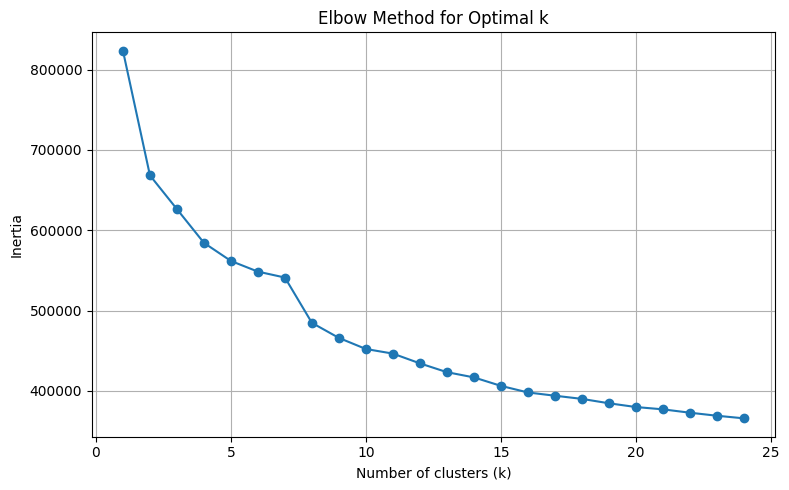

In [ ]:
# Elbow method to determine optimal k
inertia = []
k_range = range(1, 25)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.tight_layout()
plt.show()

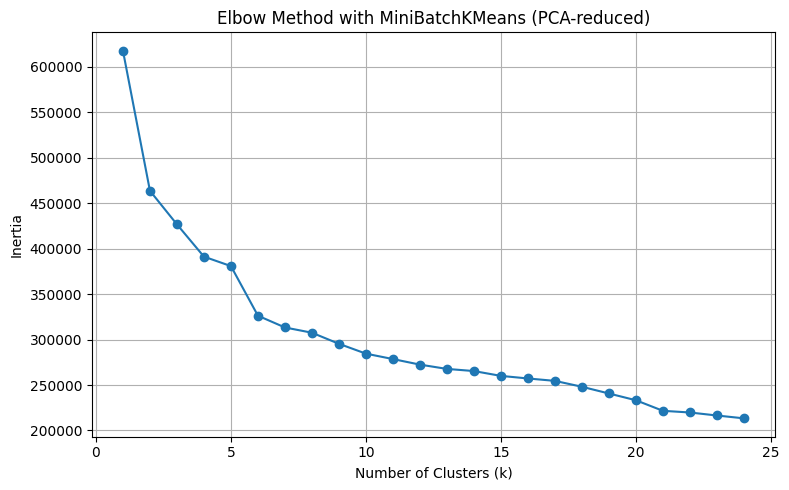

In [ ]:
from sklearn.cluster import MiniBatchKMeans

# Reduce to 10 PCA components for speed
pca = PCA(n_components=10, random_state=42)
X_pca_reduced = pca.fit_transform(X_scaled)

# Elbow method using MiniBatchKMeans
inertia = []
k_range = range(1, 25)

for k in k_range:
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=1024)
    kmeans.fit(X_pca_reduced)
    inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o', linestyle='-')
plt.title("Elbow Method with MiniBatchKMeans (PCA-reduced)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# KMeans Clustering with k=8
kmeans = KMeans(n_clusters=6, random_state=42)
clusters = kmeans.fit_predict(X_pca_reduced)

# Add cluster labels to the original DataFrame
df_C["Cluster"] = clusters

In [ ]:
# Reduce to 2D for visualization
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_scaled)

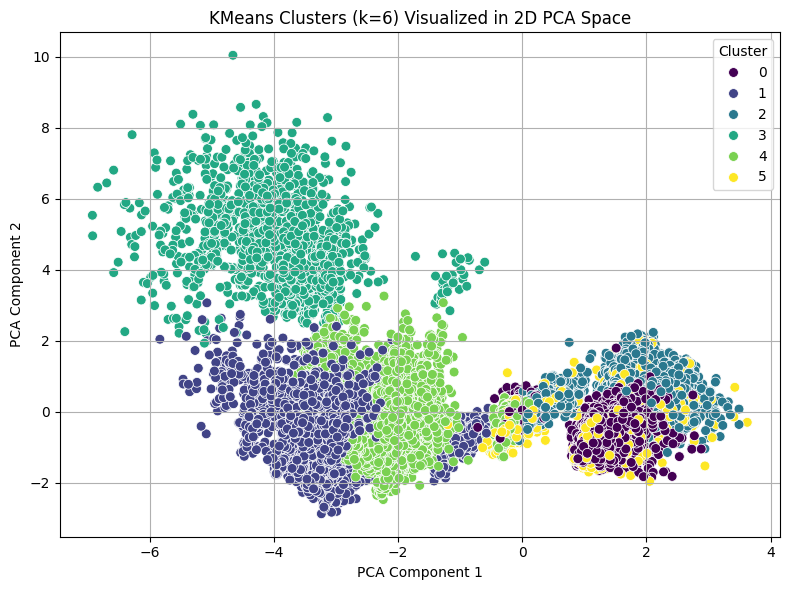

In [ ]:
# Plot clusters in 2D
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=clusters, palette="viridis", s=50)
plt.title("KMeans Clusters (k=6) Visualized in 2D PCA Space")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Cluster Profile Analysis (mean values per cluster)
profile = df_C.groupby("Cluster").mean(numeric_only=True).round(2)
print("Cluster Profiles:\n")
print(profile)

Cluster Profiles:

           age   job  marital  education  default  housing  loan  contact  \
Cluster                                                                     
0        40.20  4.09     1.15       4.09     0.24     1.09  0.02     0.03   
1        39.96  3.71     1.20       3.77     0.12     1.14  0.33     0.07   
2        40.30  3.57     1.11       3.32     0.32     0.91  0.03     0.99   
3        41.81  4.25     1.29       4.26     0.04     1.12  0.33     0.08   
4        39.30  3.52     1.26       3.78     0.10     1.18  0.29     0.10   
5        39.97  3.56     1.14       3.80     0.25     1.15  1.97     0.49   

         month  day_of_week  ...  campaign  previous  poutcome  emp.var.rate  \
Cluster                      ...                                               
0         2.51         2.18  ...      2.93      0.00      1.00          1.26   
1         4.93         1.94  ...      2.01      1.12      0.00         -1.67   
2         5.21         1.99  ...      2.84  

In [ ]:
import plotly.express as px
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Assume X_scaled is your scaled data
# PCA 3D
pca_3d = PCA(n_components=3, random_state=42)
X_3d = pca_3d.fit_transform(X_scaled)

# KMeans clustering
kmeans = KMeans(n_clusters=10, random_state=42)
clusters = kmeans.fit_predict(X_3d)

# Prepare dataframe for plotly
df_3d = pd.DataFrame(X_3d, columns=['PCA1', 'PCA2', 'PCA3'])
df_3d['Cluster'] = clusters.astype(str)  # as string for coloring

# Plotly interactive 3D scatter plot
fig = px.scatter_3d(df_3d, x='PCA1', y='PCA2', z='PCA3',
                    color='Cluster', opacity=0.7,
                    title="KMeans Clusters (k=8) in Interactive 3D PCA Space",
                    width=800, height=600)

fig.show()

In [ ]:
from sklearn.metrics import silhouette_score
score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", round(score, 3))

Silhouette Score: 0.06


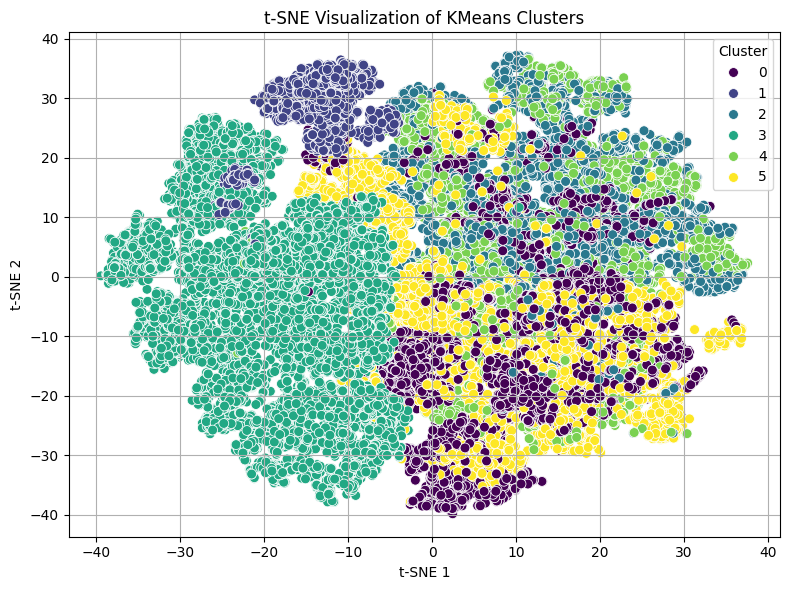

In [ ]:
from sklearn.manifold import TSNE
import seaborn as sns
import matplotlib.pyplot as plt

# Use t-SNE to reduce dimensions to 2D
tsne = TSNE(n_components=3, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

# Plot t-SNE clusters
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=clusters, palette='viridis', s=50)
plt.title("t-SNE Visualization of KMeans Clusters")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Install a compatible version of Numba
!pip install "numba<0.59"

In [ ]:
# Visualize Clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=clusters, palette="tab10", s=50)
plt.title("UMAP + DBSCAN Clustering (2D)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()